This step evaluates the temporal availability of the historical and recent detector datasets for the selected intersections. Since the older JSON files and the newer JSON files have slightly different internal structures, a unified parser is used to extract the common traffic count information. The goal is to identify full, partial, and empty days and to determine which periods are suitable for subsequent approach-based aggregation and LSTM modeling.
****

***
**LSA1-specific output folder + usable-day extraction**
***

In [2]:
from pathlib import Path
import pandas as pd

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
DAY_SUMMARY_CSV = BASE_DIR / "historical_availability_analysis" / "historical_recent_day_summary.csv"

LSA_NAME = "LD-LSA1"
OUT_DIR = BASE_DIR / "LSA1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_USABLE_DAYS_CSV = OUT_DIR / "LSA1_usable_days.csv"
OUT_DAY_STATUS_CSV = OUT_DIR / "LSA1_day_status_summary.csv"

# ============================================================
# LOAD
# ============================================================

day_summary = pd.read_csv(DAY_SUMMARY_CSV)

# ============================================================
# FILTER FOR LSA16
# ============================================================

lsa_day_summary = day_summary[day_summary["lsa"] == LSA_NAME].copy()

usable_days = lsa_day_summary[
    lsa_day_summary["model_usability"].isin(["usable", "usable_partial"])
].copy()

usable_days = usable_days.sort_values(["date_str", "source_period"]).reset_index(drop=True)

# save
lsa_day_summary.to_csv(OUT_DAY_STATUS_CSV, index=False, encoding="utf-8-sig")
usable_days.to_csv(OUT_USABLE_DAYS_CSV, index=False, encoding="utf-8-sig")

print("Saved:")
print(OUT_DAY_STATUS_CSV)
print(OUT_USABLE_DAYS_CSV)

print("\nUsable day counts:")
print(usable_days.groupby(["source_period", "model_usability"]).size())

print("\nFirst usable days:")
print(usable_days[["date_str", "source_period", "day_status", "model_usability"]].head(20))

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_day_status_summary.csv
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_usable_days.csv

Usable day counts:
source_period  model_usability
historical     usable             28
               usable_partial      2
recent         usable             13
               usable_partial     27
dtype: int64

First usable days:
      date_str source_period   day_status model_usability
0   2025-05-26    historical  partial_day  usable_partial
1   2025-05-27    historical     full_day          usable
2   2025-05-28    historical     full_day          usable
3   2025-05-29    historical     full_day          usable
4   2025-05-30    historical     full_day          usable
5   2025-05-31    historical     full_day          usable
6   2025-06-01    historical     full_day          usable
7   2025-06-02    historical     full_day          usable
8   2025-06-03    historical     full_day          usable
9   2025-06-04    

**Approach-based count aggregation for LSA16**

This step combines the historical and recent detector JSON files for LSA16 and aggregates the selected detector counts to the approach level. The result is a continuous 15-minute approach-based traffic count dataset for the west, south, east, and north inflow directions of LSA16, which forms the basis for intersection-specific forecasting.

In [3]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")

HIST_DIR = BASE_DIR / "Six_Months_Data" / "LD-LSA1"
RECENT_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA1")

OUT_DIR = BASE_DIR / "LSA1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_RAW_CSV = OUT_DIR / "LSA1_raw_long.csv"
OUT_APPROACH_CSV = OUT_DIR / "LSA1_approach_counts_15min.csv"
OUT_MAPPING_CSV = OUT_DIR / "LSA1_mapping_summary.csv"

TIMEZONE_LOCAL = "Europe/Berlin"

# ============================================================
# LSA1 MAPPING
# ============================================================

LSA1_MAPPING = {
    "street_names": {
        "west": "Rheinstraße",
        "south": "Paul-von-Denis-Straße",
        "east": "Rheinstraße",
        "north": "Maximilianstraße",
    },
    "inflow": {
        "west": [7, 9],
        "east": [14, 24, 26],
        "north": [40, 28, 30],
    },
    "outflow": {},
    "excluded_faulty_detectors": {
        "south": [11]
    }
}

# ============================================================
# HELPERS
# ============================================================

def parse_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_date_from_filename(path: Path):
    return path.stem[:10]

def safe_get(dct, keys, default=np.nan):
    cur = dct
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

# ============================================================
# READ FILES
# ============================================================

all_files = []
if HIST_DIR.exists():
    all_files += [(p, "historical") for p in sorted(HIST_DIR.glob("*.json"))]
if RECENT_DIR.exists():
    all_files += [(p, "recent") for p in sorted(RECENT_DIR.glob("*.json"))]

rows = []

for path, source_period in all_files:
    try:
        data = parse_json_file(path)
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        continue

    timeframes = data.get("timeFrames", [])

    for tf in timeframes:
        ts_utc = tf.get("timestamp")
        detectors = tf.get("detectors", [])

        if len(detectors) == 0:
            continue

        for det in detectors:
            rows.append({
                "source_period": source_period,
                "source_file": path.name,
                "date_from_name": extract_date_from_filename(path),
                "timestamp_utc": ts_utc,
                "detector_id": safe_get(det, ["id"]),
                "count": safe_get(det, ["reading", "count", "value"]),
            })

raw_df = pd.DataFrame(rows)

# ============================================================
# CLEAN / TIMESTAMPS
# ============================================================

raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], utc=True, errors="coerce")
raw_df["timestamp_berlin"] = raw_df["timestamp_utc"].dt.tz_convert(TIMEZONE_LOCAL)
raw_df["detector_id"] = pd.to_numeric(raw_df["detector_id"], errors="coerce")
raw_df["count"] = pd.to_numeric(raw_df["count"], errors="coerce")

raw_df = raw_df.dropna(subset=["timestamp_berlin", "detector_id", "count"]).copy()
raw_df = raw_df.sort_values("timestamp_berlin").reset_index(drop=True)

raw_df.to_csv(OUT_RAW_CSV, index=False, encoding="utf-8-sig")

print("Saved raw long table:")
print(OUT_RAW_CSV)
print("Raw shape:", raw_df.shape)

# ============================================================
# SAVE MAPPING SUMMARY
# ============================================================

mapping_rows = []
for approach, dets in LSA1_MAPPING["inflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": LSA1_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "inflow"
    })

for approach, dets in LSA1_MAPPING["outflow"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": "",
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "outflow"
    })

# add note about excluded faulty detector
for approach, dets in LSA1_MAPPING["excluded_faulty_detectors"].items():
    mapping_rows.append({
        "lsa": "LD-LSA1",
        "approach": approach,
        "street_name": LSA1_MAPPING["street_names"].get(approach, ""),
        "detector_ids": ", ".join(map(str, dets)),
        "direction_type": "excluded_faulty"
    })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.to_csv(OUT_MAPPING_CSV, index=False, encoding="utf-8-sig")

print("\nSaved mapping summary:")
print(OUT_MAPPING_CSV)

# ============================================================
# AGGREGATE INFLOW COUNTS
# ============================================================

approach_tables = []

for approach, dets in LSA1_MAPPING["inflow"].items():
    temp = raw_df[raw_df["detector_id"].isin(dets)].copy()

    agg = (
        temp.groupby("timestamp_berlin", as_index=False)
        .agg(count=("count", "sum"))
    )

    agg = agg.rename(columns={"count": f"LSA1_{approach}_count"})
    approach_tables.append(agg)

# merge all approaches
approach_df = None
for tbl in approach_tables:
    if approach_df is None:
        approach_df = tbl.copy()
    else:
        approach_df = approach_df.merge(tbl, on="timestamp_berlin", how="outer")

approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], utc=True, errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# helper columns
approach_df["date"] = approach_df["timestamp_berlin"].dt.strftime("%Y-%m-%d")
approach_df["time"] = approach_df["timestamp_berlin"].dt.strftime("%H:%M")
approach_df["hour"] = approach_df["timestamp_berlin"].dt.hour
approach_df["weekday"] = approach_df["timestamp_berlin"].dt.day_name()

approach_df.to_csv(OUT_APPROACH_CSV, index=False, encoding="utf-8-sig")

print("\nSaved LSA1 approach dataset:")
print(OUT_APPROACH_CSV)
print("Approach shape:", approach_df.shape)
print("\nPreview:")
print(approach_df.head())

Saved raw long table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_raw_long.csv
Raw shape: (269346, 7)

Saved mapping summary:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_mapping_summary.csv

Saved LSA1 approach dataset:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1\LSA1_approach_counts_15min.csv
Approach shape: (6413, 8)

Preview:
           timestamp_berlin  LSA1_west_count  LSA1_east_count  \
0 2025-05-26 09:30:00+00:00              450             1800   
1 2025-05-26 09:45:00+00:00              200              329   
2 2025-05-26 10:00:00+00:00              205              308   
3 2025-05-26 10:15:00+00:00              187              336   
4 2025-05-26 10:30:00+00:00              186              320   

   LSA1_north_count        date   time  hour weekday  
0                 0  2025-05-26  09:30     9  Monday  
1               156  2025-05-26  09:45     9  Monday  
2               122  2025-05-26  10:00    10  Monday  
3        

 *** 
### **Exploratory analysis of the LSA10 approach-based dataset**

This step checks the completeness and temporal structure of the LSA10 approach-level count dataset and visualizes the main traffic patterns before forecasting.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
APPROACH_CSV = BASE_DIR / "LSA1_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# safer parsing for mixed +01:00 / +02:00 timestamps
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")

# convert to Europe/Berlin local time and remove timezone for easier plotting/grouping
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA1_west_count",
    "LSA1_east_count",
    "LSA1_north_count",
]

print("Shape:", df.shape)

print("\nMissing values per count column:")
print(df[count_cols].isna().sum())

print("\nTime range:")
print(df["timestamp_berlin"].min(), "to", df["timestamp_berlin"].max())

# time gap check
time_diff = df["timestamp_berlin"].diff().value_counts().sort_index()
print("\nMost common time differences:")
print(time_diff.head(10))

print("\nBasic statistics:")
print(df[count_cols].describe())

Shape: (6413, 8)

Missing values per count column:
LSA1_west_count     0
LSA1_east_count     0
LSA1_north_count    0
dtype: int64

Time range:
2025-05-26 11:30:00 to 2026-04-16 08:45:00

Most common time differences:
timestamp_berlin
0 days 00:15:00    6379
0 days 00:30:00      21
0 days 01:00:00       1
0 days 01:15:00       1
0 days 01:45:00       2
0 days 07:15:00       1
0 days 08:15:00       1
0 days 19:45:00       1
1 days 00:15:00       1
1 days 00:30:00       1
Name: count, dtype: int64

Basic statistics:
       LSA1_west_count  LSA1_east_count  LSA1_north_count
count      6413.000000      6413.000000       6413.000000
mean        109.187588       165.589428         69.990176
std          80.285873       123.374538         53.314517
min           0.000000         0.000000          0.000000
25%          27.000000        41.000000         16.000000
50%         104.000000       156.000000         63.000000
75%         190.000000       284.000000        122.000000
max         481.0

**1)Blockwise split for LSA1 forecasting**
Since the LSA1 dataset contains a historical block and a separate recent block, the modeling workflow is defined blockwise. The historical data are used for training, while the recent data are divided into validation and test subsets. This avoids constructing sequences across the long temporal gap between the two periods.

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
APPROACH_CSV = BASE_DIR / "LSA1_approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(APPROACH_CSV)

# Safe timestamp parsing
df["timestamp_berlin"] = pd.to_datetime(df["timestamp_berlin"], utc=True, errors="coerce")
df["timestamp_berlin"] = df["timestamp_berlin"].dt.tz_convert("Europe/Berlin").dt.tz_localize(None)

df = df.sort_values("timestamp_berlin").reset_index(drop=True)

count_cols = [
    "LSA1_west_count",
    "LSA1_east_count",
    "LSA1_north_count",
]

data = df[["timestamp_berlin"] + count_cols].copy()
data[count_cols] = data[count_cols].ffill().bfill()

# ============================================================
# BLOCKWISE SPLIT
# ============================================================

historical_df = data[data["timestamp_berlin"] < "2026-01-01"].copy()
recent_df = data[data["timestamp_berlin"] >= "2026-01-01"].copy()

print("Historical shape:", historical_df.shape)
print("Recent shape:", recent_df.shape)

print("\nHistorical range:")
print(historical_df["timestamp_berlin"].min(), "to", historical_df["timestamp_berlin"].max())

print("\nRecent range:")
print(recent_df["timestamp_berlin"].min(), "to", recent_df["timestamp_berlin"].max())

Historical shape: (2787, 4)
Recent shape: (3626, 4)

Historical range:
2025-05-26 11:30:00 to 2025-06-24 12:00:00

Recent range:
2026-03-01 01:15:00 to 2026-04-16 08:45:00


**2) Validation-test split within the recent period**
The recent data are split chronologically into validation and test subsets in order to preserve the temporal order of observations.

In [6]:
# ============================================================
# SPLIT RECENT INTO VALIDATION / TEST
# ============================================================

n_recent = len(recent_df)
val_end = int(n_recent * 0.50)

val_df = recent_df.iloc[:val_end].copy()
test_df = recent_df.iloc[val_end:].copy()
train_df = historical_df.copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain range:")
print(train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())

print("\nValidation range:")
print(val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())

print("\nTest range:")
print(test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Train: (2787, 4)
Validation: (1813, 4)
Test: (1813, 4)

Train range:
2025-05-26 11:30:00 to 2025-06-24 12:00:00

Validation range:
2026-03-01 01:15:00 to 2026-03-23 08:45:00

Test range:
2026-03-23 09:00:00 to 2026-04-16 08:45:00


**3)Sequence generation for LSA16**
The approach-based traffic count series are transformed into sequential samples for one-step-ahead forecasting. The previous four 15-minute observations are used to predict the next 15-minute traffic state.


In [7]:
# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4
HORIZON = 1

# ============================================================
# SCALE USING TRAIN ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled = scaler.transform(val_df[count_cols])
test_scaled = scaler.transform(test_df[count_cols])

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

X_train: (2783, 4, 3) y_train: (2783, 3)
X_val:   (1809, 4, 3) y_val: (1809, 3)
X_test:  (1809, 4, 3) y_test: (1809, 3)


**4) Naive baseline for LSA16**
A persistence-based baseline is used as a benchmark. It predicts that the next traffic state is equal to the most recent observed state.

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Naive prediction = last observed step in the input sequence
y_pred_naive_scaled = X_test[:, -1, :]

# Back to original counts
y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

print("LSA1 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

LSA1 Naive baseline:
MAE : 14.038
RMSE: 22.298


**LSTM model for LSA1**
An LSTM model is trained to predict the next 15-minute traffic counts for the four inflow approaches of LSA16.

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,603 (68.76 KB)

 Trainable params: 17,603 (68.76 KB)

 Non-trainable params: 0 (0.00 B)

**6) Training of the LSTM model**
The model is trained on the historical data and validated on the early recent period. Early stopping is used to reduce overfitting.


In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0325 - val_loss: 0.0041
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 9/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 10/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 11/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 12/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025 - val_lo

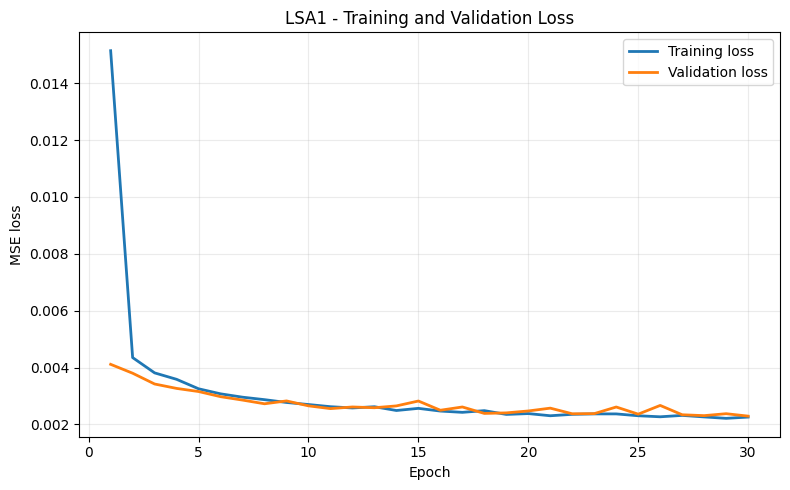

   epoch  train_loss  val_loss
0      1    0.015141  0.004113
1      2    0.004350  0.003801
2      3    0.003813  0.003422
3      4    0.003586  0.003266
4      5    0.003253  0.003157


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "epoch": range(1, len(history.history["loss"]) + 1),
    "train_loss": history.history["loss"],
    "val_loss": history.history["val_loss"]
})

plt.figure(figsize=(8, 5))
plt.plot(loss_df["epoch"], loss_df["train_loss"], label="Training loss", linewidth=2)
plt.plot(loss_df["epoch"], loss_df["val_loss"], label="Validation loss", linewidth=2)
plt.title("LSA1 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(loss_df.head())

The training and validation loss curves for LSA1 indicate a stable and well-behaved learning process. Both losses decrease sharply during the first epochs and then gradually converge to low values, showing that the model is able to learn meaningful temporal traffic patterns from the available data. After the initial training phase, the validation loss remains close to the training loss and is in some epochs even slightly lower. This can be explained by the use of dropout regularization during training, which makes the training task slightly harder, while dropout is inactive during validation. In addition, the recent validation period may contain more regular short-term traffic patterns than parts of the historical training set. The absence of a strong upward divergence in the validation loss suggests that the model does not suffer from severe overfitting and is able to generalize reasonably well to unseen LSA1 data.

**7)Evaluation of the LSA1 LSTM model**
The trained LSTM model is evaluated on the unseen recent test period and compared with the naive baseline.

In [12]:
y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

print("LSA1 Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

print("\nLSA1 LSTM:")
print("MAE :", round(overall_mae_lstm, 3))
print("RMSE:", round(overall_rmse_lstm, 3))

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
LSA1 Naive baseline:
MAE : 14.038
RMSE: 22.298

LSA1 LSTM:
MAE : 13.691
RMSE: 21.832


   model        MAE       RMSE
0  Naive  14.038327  22.297584
1   LSTM  13.691322  21.831899


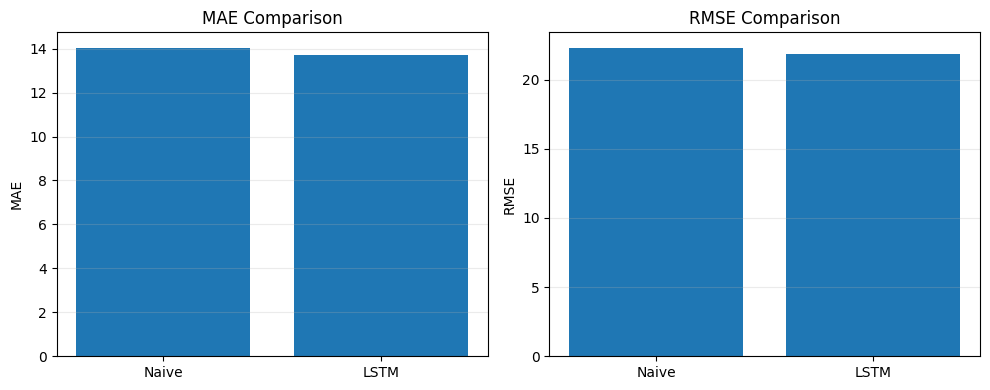

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    "model": ["Naive", "LSTM"],
    "MAE": [overall_mae_naive, overall_mae_lstm],
    "RMSE": [overall_rmse_naive, overall_rmse_lstm]
})

print(metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(metrics_df["model"], metrics_df["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(metrics_df["model"], metrics_df["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

per-approach MAE and RMSE 

  approach  naive_MAE   lstm_MAE  naive_RMSE  lstm_RMSE
0     west  13.754561  13.368066   21.576762  20.069504
1     east  17.576009  18.560976   26.176813  28.038074
2    north  10.784411   9.144926   18.459808  15.523429


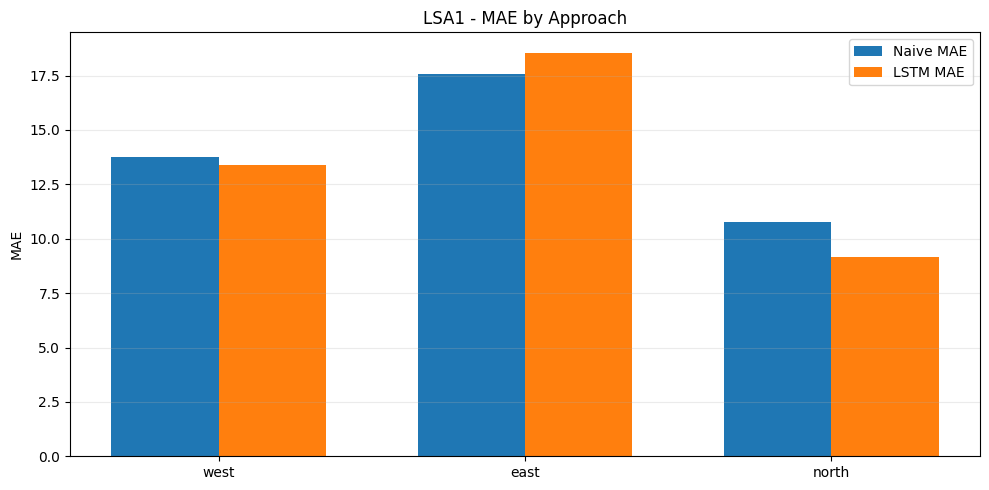

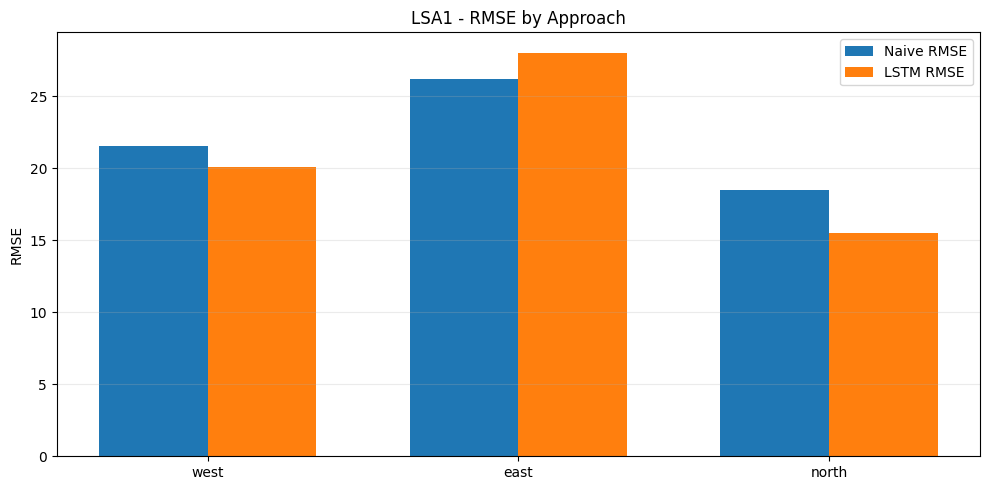

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rows = []
for i, feature in enumerate(count_cols):
    rows.append({
        "approach": feature.replace("LSA1_", "").replace("_count", ""),
        "naive_MAE": mean_absolute_error(y_test_actual[:, i], y_pred_naive_actual[:, i]),
        "lstm_MAE": mean_absolute_error(y_test_actual[:, i], y_pred_lstm_actual[:, i]),
        "naive_RMSE": rmse(y_test_actual[:, i], y_pred_naive_actual[:, i]),
        "lstm_RMSE": rmse(y_test_actual[:, i], y_pred_lstm_actual[:, i]),
    })

per_feature_df = pd.DataFrame(rows)
print(per_feature_df)

x = np.arange(len(per_feature_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, per_feature_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA1 - MAE by Approach")
plt.ylabel("MAE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, per_feature_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, per_feature_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, per_feature_df["approach"])
plt.title("LSA1 - RMSE by Approach")
plt.ylabel("RMSE")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

since east heavily loaded, more error lies there

**8)Visualization of actual, naive, and LSTM predictions for LSA1**
This step compares the observed traffic counts with the naive baseline and LSTM forecasts for the four LSA1 inflow approaches.

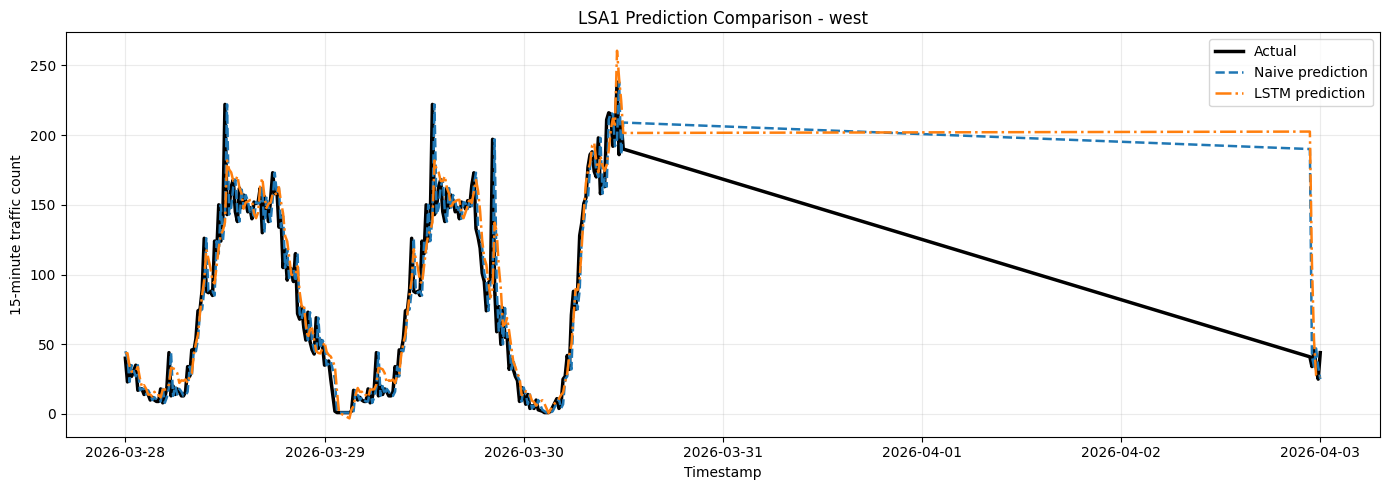

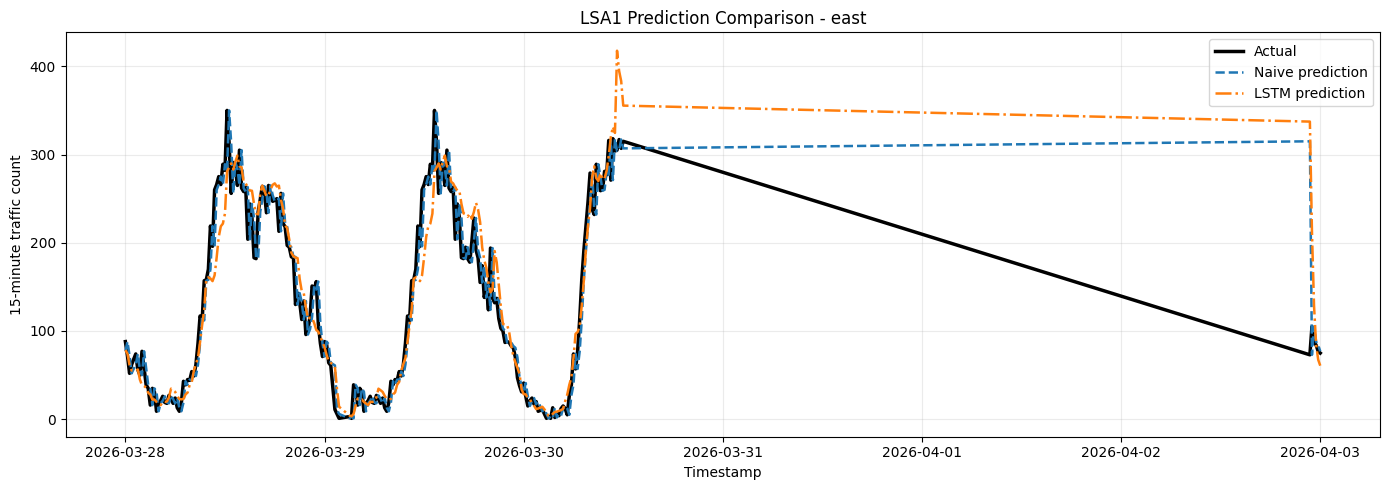

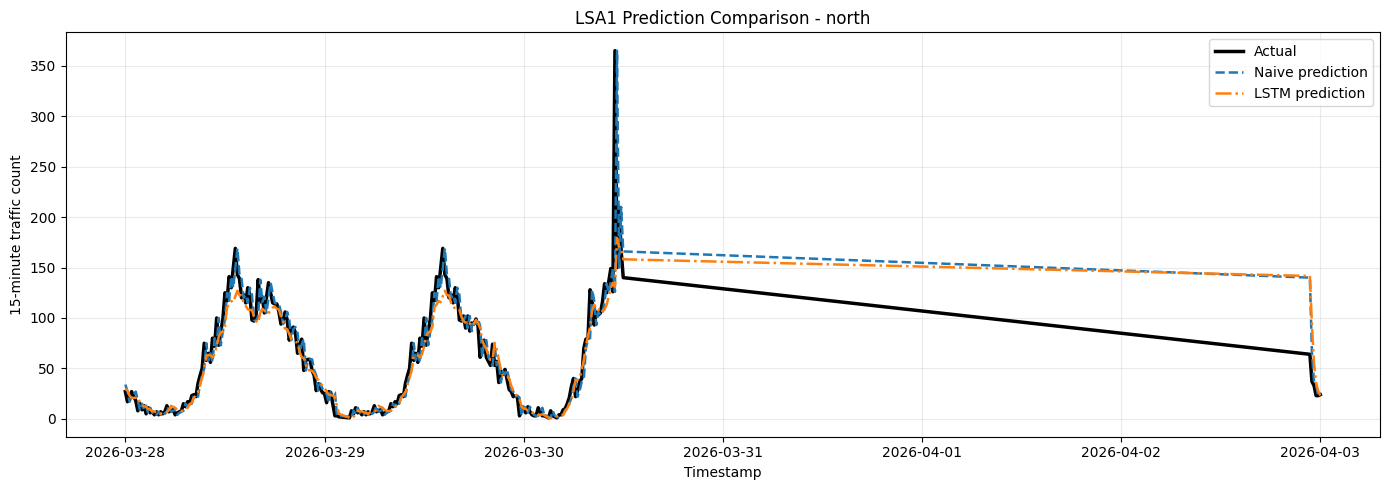

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

plot_features = count_cols.copy()

# choose a shorter visible window inside the test period
# examples:
# window_start = "2026-03-28"
# window_end   = "2026-04-02"

window_start = "2026-03-28"
window_end   = "2026-04-03"

test_timestamps = test_df["timestamp_berlin"].iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)

mask = (test_timestamps >= window_start) & (test_timestamps <= window_end)

plot_timestamps = test_timestamps[mask]

for feature in plot_features:
    idx = count_cols.index(feature)

    actual = y_test_actual[:, idx][mask]
    naive = y_pred_naive_actual[:, idx][mask]
    lstm = y_pred_lstm_actual[:, idx][mask]

    plt.figure(figsize=(14, 5))

    plt.plot(plot_timestamps, actual, label="Actual", linewidth=2.5, color="black")
    plt.plot(plot_timestamps, naive, label="Naive prediction", linestyle="--", linewidth=1.8)
    plt.plot(plot_timestamps, lstm, label="LSTM prediction", linestyle="-.", linewidth=1.8)

    plt.title(f"LSA1 Prediction Comparison - {feature.replace('LSA1_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Data Availability**

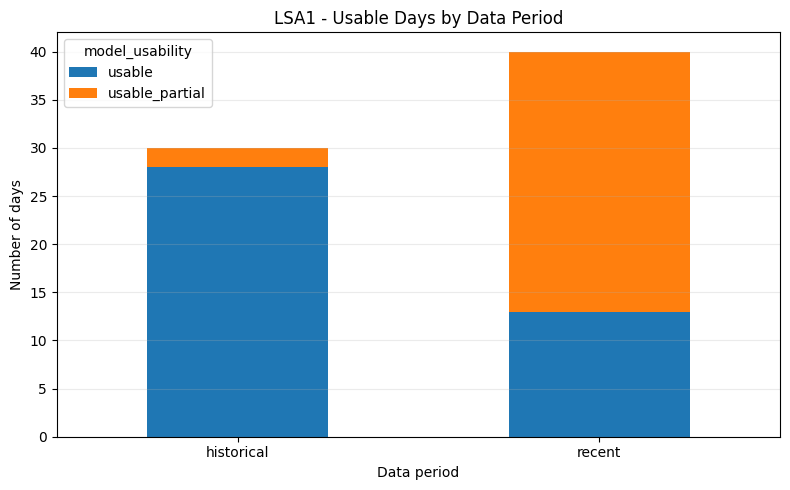

model_usability  usable  usable_partial
source_period                          
historical           28               2
recent               13              27


In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model\LSA1")
USABLE_DAYS_CSV = BASE_DIR / "LSA1_usable_days.csv"

# ============================================================
# LOAD
# ============================================================

usable_days = pd.read_csv(USABLE_DAYS_CSV)

summary = (
    usable_days.groupby(["source_period", "model_usability"])
    .size()
    .unstack(fill_value=0)
)

# keep clean order
for col in ["usable", "usable_partial"]:
    if col not in summary.columns:
        summary[col] = 0

summary = summary[["usable", "usable_partial"]]

ax = summary.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("LSA1 - Usable Days by Data Period")
ax.set_xlabel("Data period")
ax.set_ylabel("Number of days")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(summary)

**Epoch**

An epoch means one full pass through the training dataset.
If i train for 30 epochs, the model sees the full training data 30 times and updates its weights each time.

**Dropout**

Dropout is a regularization method. During training, it randomly ignores a fraction of neurons, here 20%, so that the model does not rely too heavily on specific patterns. This helps reduce overfitting and improves generalization to unseen data.

**Training loss**

The training loss is the model’s error on the training set during learning. It shows how well the model fits the data it is trained on.

**Validation loss**

The validation loss is the model’s error on unseen validation data after each epoch. It is important because it shows whether the model is learning patterns that generalize, rather than just memorizing the training data.

**MAE**

MAE means Mean Absolute Error. It tells, on average, how many vehicles the prediction is off by, without squaring the errors.

**RMSE**

RMSE means Root Mean Squared Error. It is similar to MAE but penalizes large errors more strongly. So it is more sensitive to spikes and bigger mistakes.

My result

For LSA16:

Naive MAE = 9.304
LSTM MAE = 7.542
Naive RMSE = 14.665
LSTM RMSE = 11.735

This means the LSTM made smaller average errors and also fewer large errors than the naive baseline.

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 12
HORIZONS = [1, 2, 4]   # 15 min, 30 min, 60 min

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

def build_lstm_model(lookback, n_features):
    model = Sequential([
        LSTM(64, input_shape=(lookback, n_features)),
        Dropout(0.2),
        Dense(n_features)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# ============================================================
# SCALE USING TRAIN DATA ONLY
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[count_cols])

train_scaled = scaler.transform(train_df[count_cols])
val_scaled   = scaler.transform(val_df[count_cols])
test_scaled  = scaler.transform(test_df[count_cols])

# ============================================================
# LOOP OVER HORIZONS
# ============================================================

results = []

for horizon in HORIZONS:
    print("=" * 70)
    print(f"HORIZON = {horizon} step(s) = {horizon * 15} minutes ahead")

    # create sequences
    X_train, y_train = create_sequences(train_scaled, LOOKBACK, horizon)
    X_val, y_val     = create_sequences(val_scaled, LOOKBACK, horizon)
    X_test, y_test   = create_sequences(test_scaled, LOOKBACK, horizon)

    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
    print("X_test: ", X_test.shape, "y_test:", y_test.shape)

    # actual values in original scale
    y_test_actual = scaler.inverse_transform(y_test)

    # ========================================================
    # NAIVE BASELINE
    # ========================================================
    y_pred_naive_scaled = X_test[:, -1, :]
    y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

    overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
    overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

    # ========================================================
    # LSTM
    # ========================================================
    n_features = X_train.shape[2]

    model = build_lstm_model(LOOKBACK, n_features)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_lstm_scaled = model.predict(X_test, verbose=0)
    y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

    overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
    overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

    print("Naive  -> MAE:", round(overall_mae_naive, 3), "| RMSE:", round(overall_rmse_naive, 3))
    print("LSTM   -> MAE:", round(overall_mae_lstm, 3), "| RMSE:", round(overall_rmse_lstm, 3))

    results.append({
        "horizon_steps": horizon,
        "horizon_minutes": horizon * 15,
        "naive_MAE": overall_mae_naive,
        "naive_RMSE": overall_rmse_naive,
        "lstm_MAE": overall_mae_lstm,
        "lstm_RMSE": overall_rmse_lstm,
        "mae_improvement_percent": (overall_mae_naive - overall_mae_lstm) / overall_mae_naive * 100,
        "rmse_improvement_percent": (overall_rmse_naive - overall_rmse_lstm) / overall_rmse_naive * 100,
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_trained": len(history.history["loss"])
    })

results_df = pd.DataFrame(results)

print("\nFinal comparison table:")
print(results_df)

HORIZON = 1 step(s) = 15 minutes ahead
X_train: (2775, 12, 3) y_train: (2775, 3)
X_val:   (1801, 12, 3) y_val: (1801, 3)
X_test:  (1801, 12, 3) y_test: (1801, 3)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 14.035 | RMSE: 22.308
LSTM   -> MAE: 13.636 | RMSE: 21.594
HORIZON = 2 step(s) = 30 minutes ahead
X_train: (2774, 12, 3) y_train: (2774, 3)
X_val:   (1800, 12, 3) y_val: (1800, 3)
X_test:  (1800, 12, 3) y_test: (1800, 3)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 16.901 | RMSE: 26.958
LSTM   -> MAE: 15.54 | RMSE: 25.183
HORIZON = 4 step(s) = 60 minutes ahead
X_train: (2772, 12, 3) y_train: (2772, 3)
X_val:   (1798, 12, 3) y_val: (1798, 3)
X_test:  (1798, 12, 3) y_test: (1798, 3)


c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Naive  -> MAE: 23.9 | RMSE: 37.601
LSTM   -> MAE: 19.182 | RMSE: 30.992

Final comparison table:
   horizon_steps  horizon_minutes  naive_MAE  naive_RMSE   lstm_MAE  \
0              1               15  14.034981   22.308129  13.636344   
1              2               30  16.901296   26.958284  15.539537   
2              4               60  23.899518   37.601431  19.181768   

   lstm_RMSE  mae_improvement_percent  rmse_improvement_percent  \
0  21.593728                 2.840308                  3.202422   
1  25.182725                 8.057130                  6.586319   
2  30.992301                19.739937                 17.576805   

   best_val_loss  epochs_trained  
0       0.002313              30  
1       0.003109              22  
2       0.004346              30  


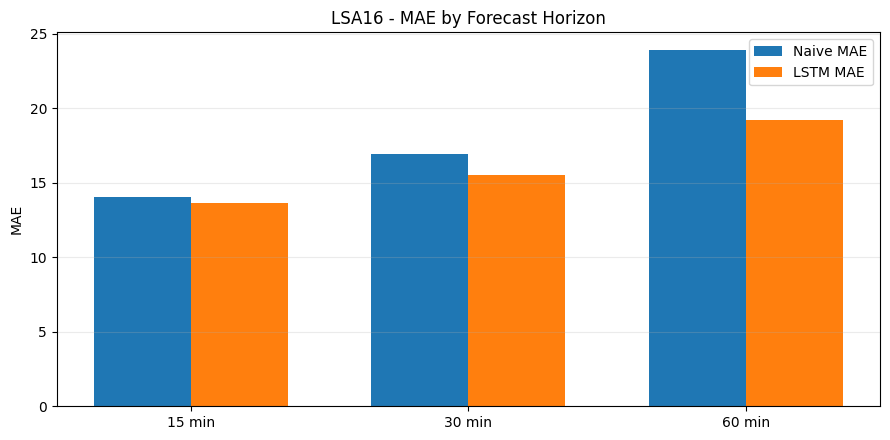

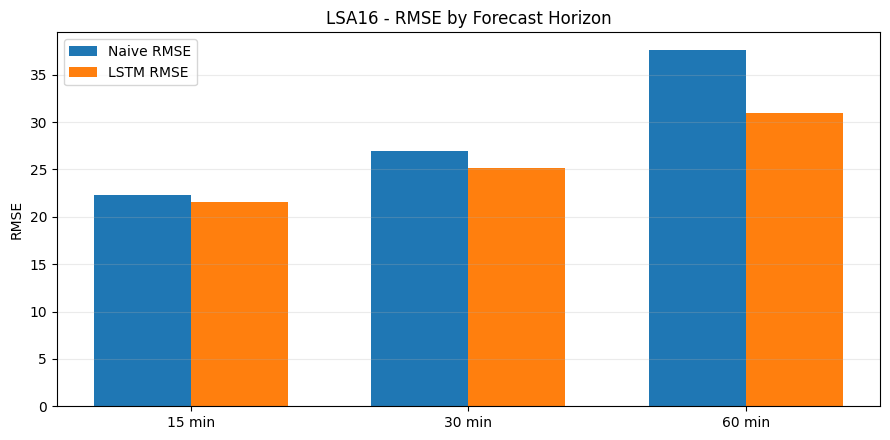

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results_df))
labels = [f"{m} min" for m in results_df["horizon_minutes"]]

width = 0.35

# MAE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_MAE"], width, label="Naive MAE")
plt.bar(x + width/2, results_df["lstm_MAE"], width, label="LSTM MAE")
plt.xticks(x, labels)
plt.ylabel("MAE")
plt.title("LSA16 - MAE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, results_df["naive_RMSE"], width, label="Naive RMSE")
plt.bar(x + width/2, results_df["lstm_RMSE"], width, label="LSTM RMSE")
plt.xticks(x, labels)
plt.ylabel("RMSE")
plt.title("LSA16 - RMSE by Forecast Horizon")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

LSA1 presents a more challenging forecasting case than LSA16 and LSA10 due to its shorter historical training period, higher proportion of partial recent days, and more irregular traffic dynamics. Nevertheless, the LSTM model still outperforms the naive baseline at all tested horizons. The improvement is relatively small for 15-minute forecasting, where persistence remains highly competitive, but becomes substantially larger at 30-minute and especially 60-minute horizons. This suggests that, for LSA1, the added value of the LSTM emerges more clearly as the prediction task becomes more difficult.

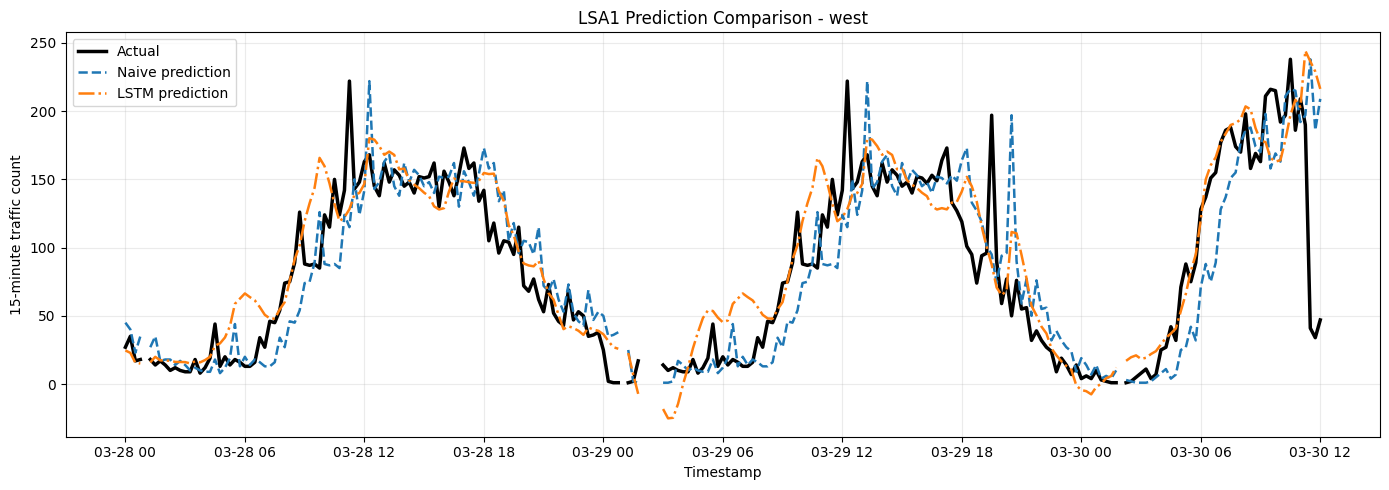

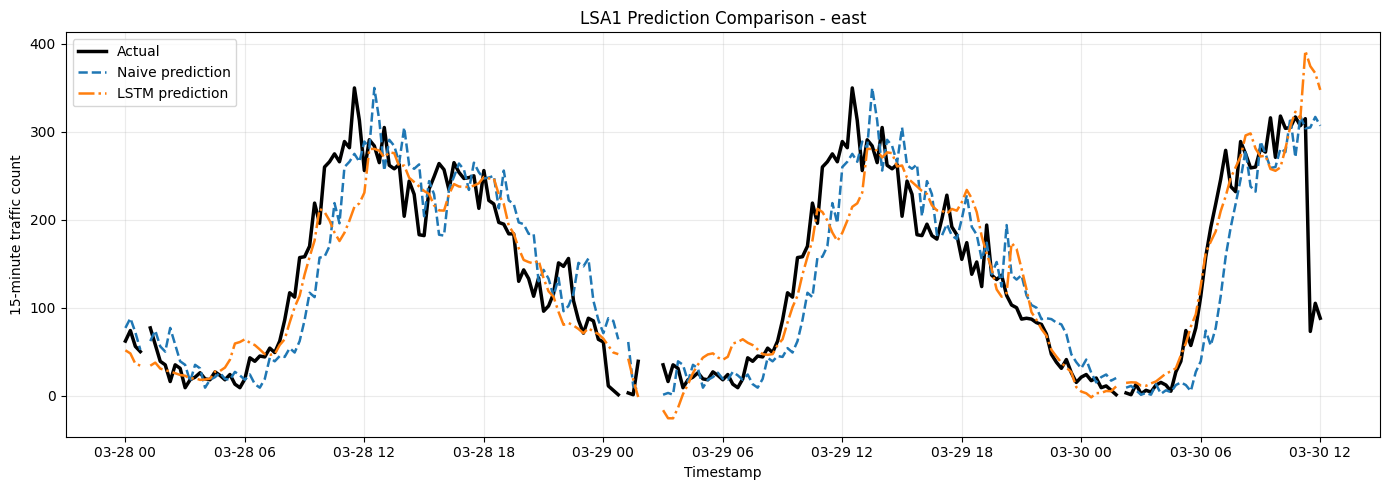

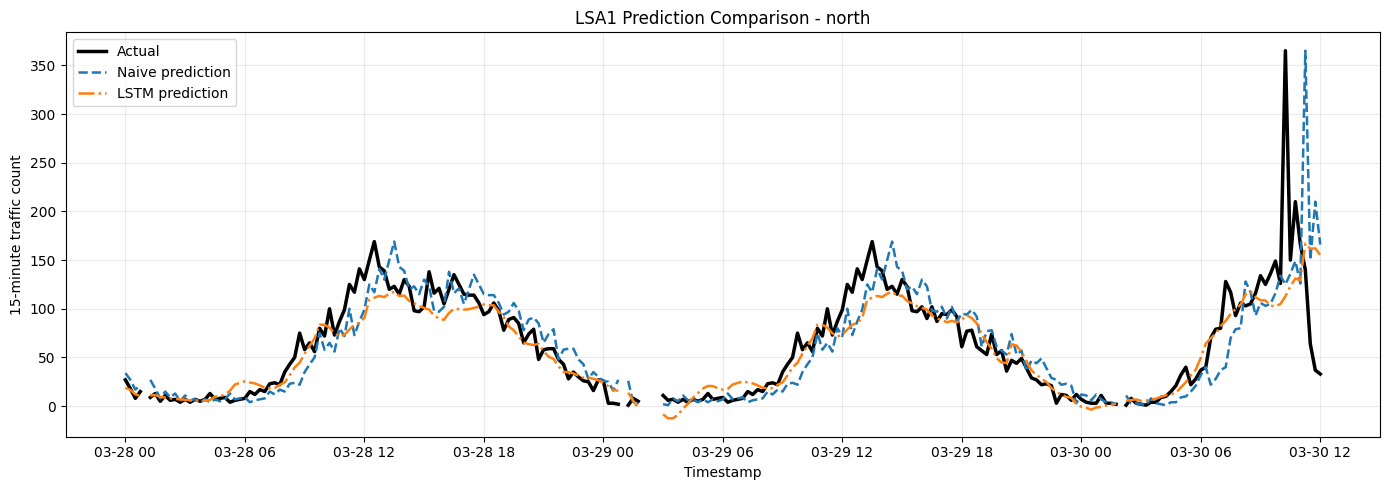

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

plot_features = count_cols.copy()

full_test_timestamps = test_df["timestamp_berlin"].reset_index(drop=True)
aligned_test_timestamps = full_test_timestamps.iloc[
    LOOKBACK + HORIZON - 1 : LOOKBACK + HORIZON - 1 + len(y_test_actual)
].reset_index(drop=True)

window_start = pd.Timestamp("2026-03-28")
window_end   = pd.Timestamp("2026-03-30 23:59:59")

window_mask = (aligned_test_timestamps >= window_start) & (aligned_test_timestamps <= window_end)
plot_timestamps = aligned_test_timestamps[window_mask].reset_index(drop=True)

for feature in plot_features:
    idx = count_cols.index(feature)

    plot_df = pd.DataFrame({
        "timestamp": plot_timestamps,
        "actual": y_test_actual[window_mask, idx],
        "naive": y_pred_naive_actual[window_mask, idx],
        "lstm": y_pred_lstm_actual[window_mask, idx],
    })

    plot_df["gap"] = plot_df["timestamp"].diff() > pd.Timedelta(minutes=15)
    plot_df["segment"] = plot_df["gap"].cumsum()

    plt.figure(figsize=(14, 5))

    for seg_id, seg in plot_df.groupby("segment"):
        plt.plot(
            seg["timestamp"], seg["actual"],
            color="black", linewidth=2.5,
            label="Actual" if seg_id == 0 else ""
        )
        plt.plot(
            seg["timestamp"], seg["naive"],
            color="tab:blue", linestyle="--", linewidth=1.8,
            label="Naive prediction" if seg_id == 0 else ""
        )
        plt.plot(
            seg["timestamp"], seg["lstm"],
            color="tab:orange", linestyle="-.", linewidth=1.8,
            label="LSTM prediction" if seg_id == 0 else ""
        )

    plt.title(f"LSA1 Prediction Comparison - {feature.replace('LSA1_', '').replace('_count', '')}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

In [20]:
recent_check = df[
    (df["timestamp_berlin"] >= "2026-03-28") &
    (df["timestamp_berlin"] <= "2026-04-03")
].copy()

recent_check["diff"] = recent_check["timestamp_berlin"].diff()

print(recent_check[recent_check["diff"] > pd.Timedelta(minutes=15)][["timestamp_berlin", "diff"]])

        timestamp_berlin            diff
4894 2026-03-28 01:15:00 0 days 00:30:00
4989 2026-03-29 01:15:00 0 days 00:30:00
4992 2026-03-29 03:00:00 0 days 01:15:00
5084 2026-03-30 02:15:00 0 days 00:30:00
5124 2026-04-02 22:45:00 3 days 10:45:00


The unusual straight-line segments observed in the initial LSA1 prediction plots were caused by discontinuities in the recent test period rather than by model failure. A detailed inspection of the timestamps revealed several short gaps and one major gap of more than three days within the selected plotting window. Since standard line plots connect consecutive available observations regardless of the size of the temporal gap, this produced visually misleading diagonal segments. After identifying the missing intervals, shorter continuous windows and gap-aware plotting were used for a more accurate visual comparison of observed and predicted traffic counts.